In [5]:
pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.0/698.0 kB 44.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 65.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]1/2 [pmdarima]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

In [3]:
url = ('../data/raw/sales.csv')
data = pd.read_csv(url)

# Convertir a serie temporal

In [7]:
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
ts = data['sales']

# Análisis de la serie temporal

In [8]:
print("Análisis de la serie temporal:")
print(f"Tensor: {ts.index.freq or 'Diario'}")
print(f"Rango: {ts.index.min()} a {ts.index.max()}")
print(f"Número de observaciones: {len(ts)}")

Análisis de la serie temporal:
Tensor: Diario
Rango: 2022-09-03 17:10:08.079328 a 2023-09-03 17:10:08.079328
Número de observaciones: 366


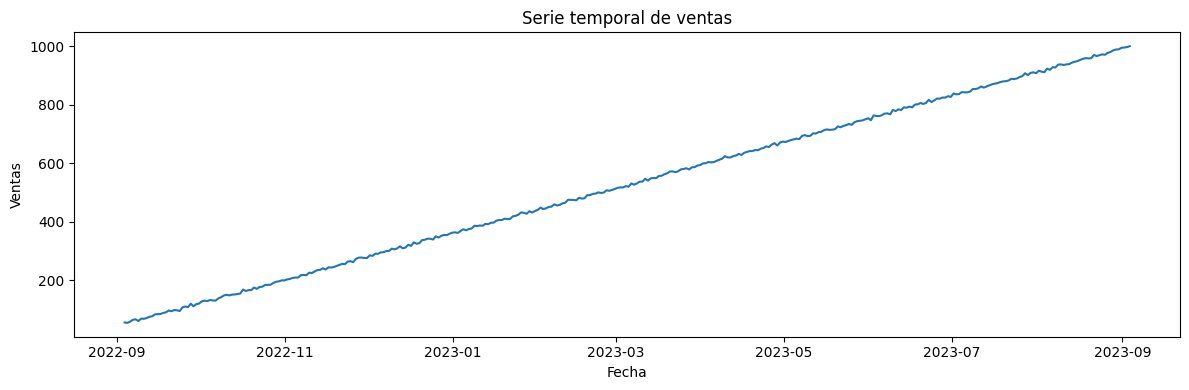

In [11]:
# Visualización
plt.figure(figsize=(12, 4))
plt.plot(ts)
plt.title('Serie temporal de ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.tight_layout()
plt.savefig('serie_temporal.png')
plt.show()

In [12]:
# Descomposición
decomposition = seasonal_decompose(ts, model='additive', period=30)
print(f"\nTendencia: {'Creciente' if decomposition.trend.dropna().iloc[-1] > decomposition.trend.dropna().iloc[0] else 'Decreciente'}")


Tendencia: Creciente


In [13]:
# Test de estacionariedad
def test_stationarity(timeseries):
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    return dftest[1]

p_value = test_stationarity(ts)
print(f"¿Es estacionaria?: {'No' if p_value > 0.05 else 'Sí'} (p-value: {p_value:.4f})")
print(f"Variabilidad: Desviación estándar = {ts.std():.2f}")

¿Es estacionaria?: No (p-value: 0.9862)
Variabilidad: Desviación estándar = 275.09


# Entrenamiento del modelo ARIMA

In [14]:
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

print("\nEntrenando modelo ARIMA...")
model = auto_arima(train, seasonal=False, trace=False, suppress_warnings=True)
print(f"Mejor modelo: {model.order}")



Entrenando modelo ARIMA...
Mejor modelo: (0, 1, 1)


Predicción y evaluación

In [15]:
forecast = model.predict(n_periods=len(test))
forecast_series = pd.Series(forecast, index=test.index)

mse = mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mse)

print(f"\nMétricas de rendimiento:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Métricas de rendimiento:
MAE: 2.23
RMSE: 2.80


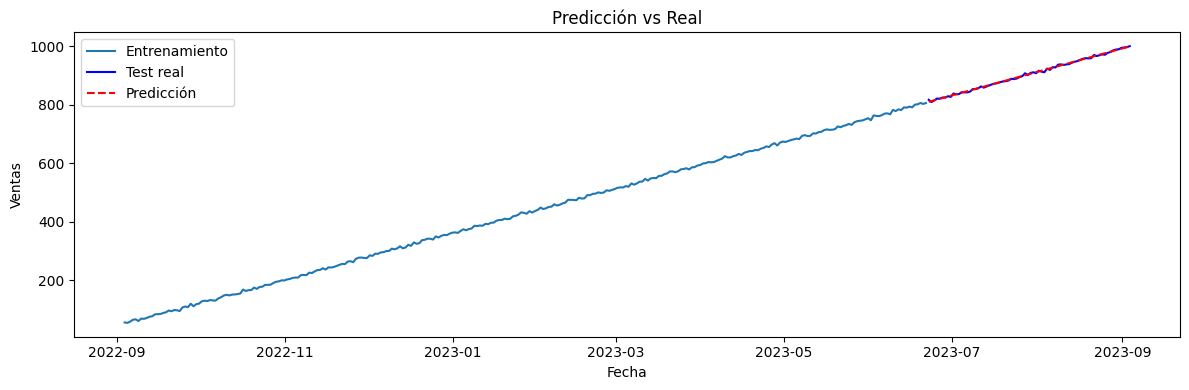

In [16]:
# Visualización de predicciones
plt.figure(figsize=(12, 4))
plt.plot(train, label='Entrenamiento')
plt.plot(test, label='Test real', color='blue')
plt.plot(forecast_series, label='Predicción', color='red', linestyle='--')
plt.title('Predicción vs Real')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.tight_layout()
plt.show()

GUARDAR MODELO

In [17]:
with open('modelo_arima.pkl', 'wb') as f:
    pickle.dump(model, f)

print("\nModelo guardado exitosamente como 'modelo_arima.pkl'")


Modelo guardado exitosamente como 'modelo_arima.pkl'
